Dataset Preview:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

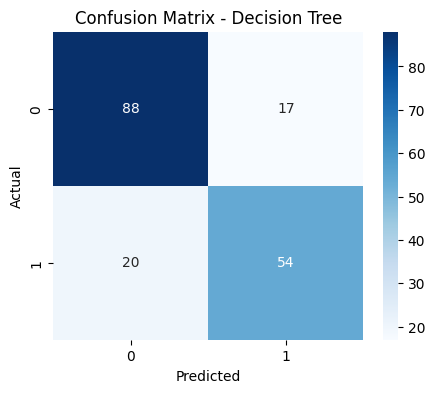


=== Random Forest ===
Accuracy: 0.8044692737430168
Confusion Matrix:
 [[90 15]
 [20 54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



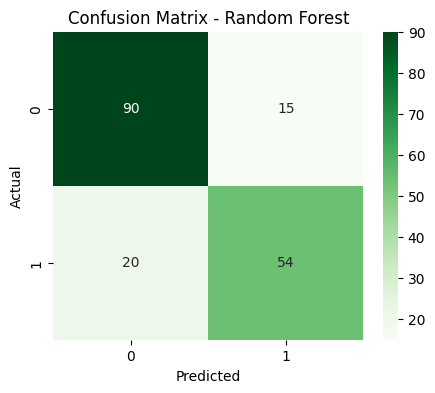


=== HYPERPARAMETER TUNING ===
Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Best Accuracy: 0.8384615384615384


In [1]:
# ================= STEP 1: IMPORT LIBRARIES =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ================= STEP 2: LOAD DATASET =================
df = pd.read_csv("Titanic-Dataset.csv")


print("Dataset Preview:\n", df.head())
print("\nDataset Shape:", df.shape)


# ================= STEP 3: DATA PREPROCESSING =================
# FIXED WARNING ISSUE (no inplace)


df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


# Convert categorical to numeric
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


# Drop unnecessary columns
df = df.drop(columns=['Name', 'PassengerId', 'Ticket', 'Cabin'])


# ================= STEP 4: FEATURES & TARGET =================
X = df.drop(columns=['Survived'])
y = df['Survived']


# ================= STEP 5: TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================= DECISION TREE =================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


y_pred_dt = dt.predict(X_test)


print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))


# 📊 Decision Tree Confusion Matrix Image
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt="d", cmap="Blues")


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()




# ================= RANDOM FOREST =================
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


y_pred_rf = rf.predict(X_test)


print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


# 📊 Random Forest Confusion Matrix Image
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt="d", cmap="Greens")


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()




# ================= HYPERPARAMETER TUNING =================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}


grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)


print("\n=== HYPERPARAMETER TUNING ===")
print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

